In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
data=load_breast_cancer()
df=pd.DataFrame(data.data,columns=data.feature_names)
df['target']=data.target
print('Dataset Loaded')
df.shape
df.head()

Dataset Loaded


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


/tmp/ipykernel_6130/827074563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target',data=df,palette='Set2')


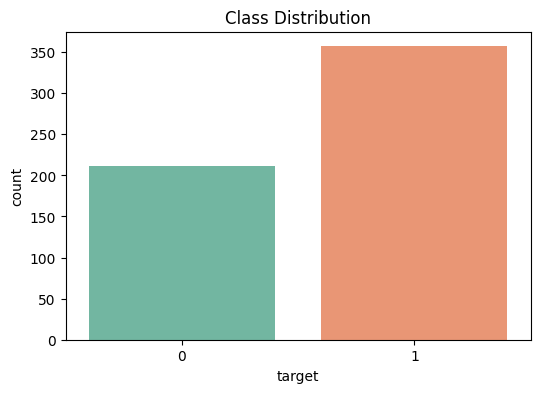

In [3]:
plt.figure(figsize=(6,4))
sns.countplot(x='target',data=df,palette='Set2')
plt.title('Class Distribution')
plt.show()

In [4]:
X=df.drop('target',axis=1)
Y=df['target']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
print("Data split is Done!")
print("Train size",X_train.shape)
print("Test size",X_test.shape)

Data split is Done!
Train size (455, 30)
Test size (114, 30)


In [5]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,Y_train)
lr_pred=lr.predict(X_test)
dt=DecisionTreeClassifier(random_state=42)
dt.fit(X_train,Y_train)
dt_pred=dt.predict(X_test)
print("Logidtic Regrssion",accuracy_score(Y_test,lr_pred))
print("Decision Tree Classifier",accuracy_score(Y_test,dt_pred))

Logidtic Regrssion 0.9736842105263158
Decision Tree Classifier 0.9473684210526315


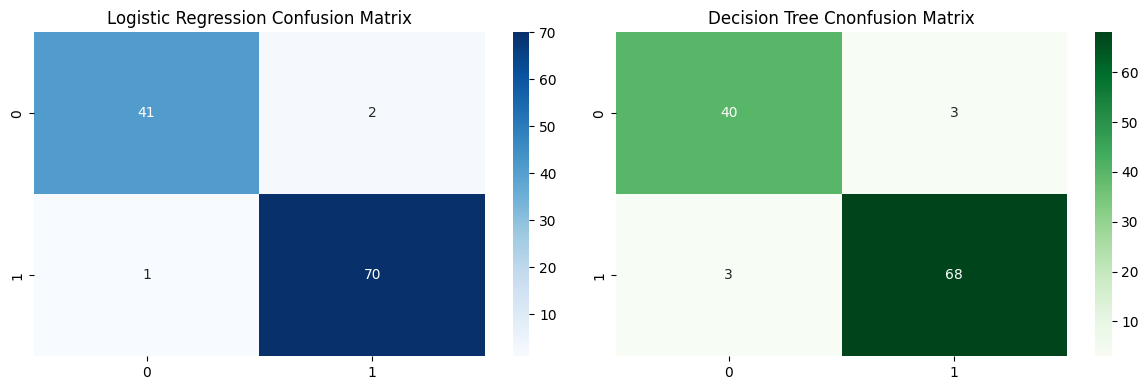

In [6]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
cm_lr=confusion_matrix(Y_test,lr_pred)
sns.heatmap(cm_lr,annot=True,fmt='d',cmap='Blues',ax=axes[0])
axes[0].set_title('Logistic Regression Confusion Matrix')
cm_dt=confusion_matrix(Y_test,dt_pred)
sns.heatmap(cm_dt,annot=True,fmt='d',cmap='Greens',ax=axes[1])
axes[1].set_title('Decision Tree Cnonfusion Matrix')
plt.tight_layout()
plt.show()

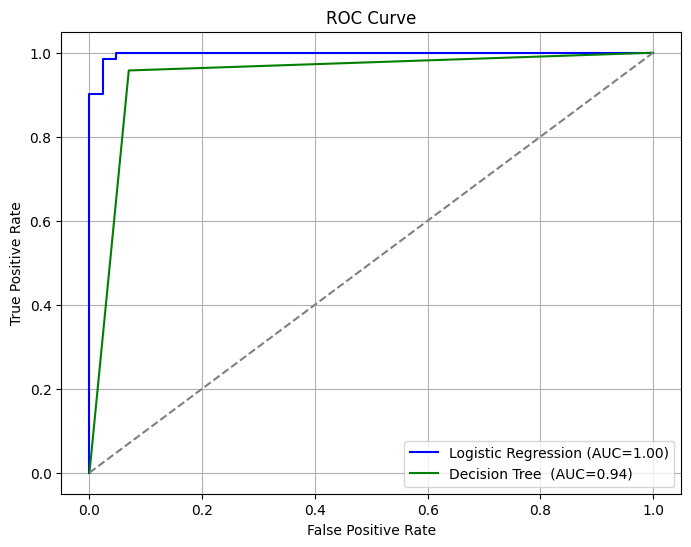

In [7]:
plt.figure(figsize=(8,6))
lr_probs=lr.predict_proba(X_test)[:,1]
fpr1,tpr1,_=roc_curve(Y_test,lr_probs)
plt.plot(fpr1,tpr1,label=f'Logistic Regression (AUC={auc(fpr1,tpr1):.2f})',color='blue')
dt_probs=dt.predict_proba(X_test)[:,1]
fpr2,tpr2,_=roc_curve(Y_test,dt_probs)
plt.plot(fpr2,tpr2,label=f'Decision Tree  (AUC={auc(fpr2,tpr2):.2f})',color='green')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()

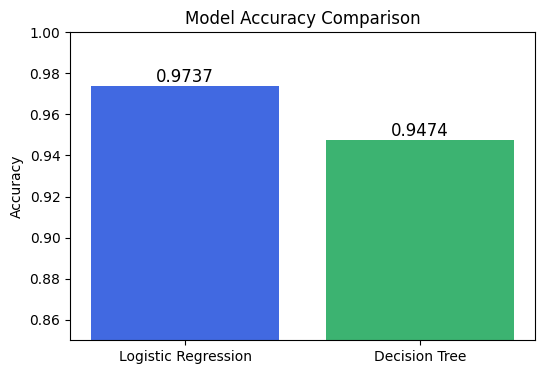

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [8]:
models = ['Logistic Regression', 'Decision Tree']
accuracies = [accuracy_score(Y_test, lr_pred),
              accuracy_score(Y_test, dt_pred)]

plt.figure(figsize=(6,4))
bars = plt.bar(models, accuracies,
               color=['royalblue','mediumseagreen'])
plt.ylim(0.85, 1.0)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.002,
             f'{acc:.4f}', ha='center', fontsize=12)
plt.show()

print("=== Logistic Regression ===")
print(classification_report(Y_test, lr_pred))
print("=== Decision Tree ===")
print(classification_report(Y_test, dt_pred))